# Analysis Cross-Comparison & Calculated Similarities

Naive baseline approach: cross-compares every reference word against every hypothesis word
cross-comparison without 1:1 alignment constraint).


## Imports


In [1]:
import sys
import importlib
from pathlib import Path

# locate project root by walking up until requirements.txt is found
_anchor = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (_anchor, *_anchor.parents) if (p / "requirements.txt").exists())
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "domain"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "utils"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments" / "cross_comparison"))

import pandas as pd

import preprocessing
import word_similarity_calculator
import plot_helpers
importlib.reload(preprocessing)
importlib.reload(word_similarity_calculator)
importlib.reload(plot_helpers)

from cross_comparison import generate_cross_comparison_df
from word_similarity_calculator import WordSimilarityCalculator
from preprocessing import clean_word


In [2]:
SAMPLES_METADATA = PROJECT_ROOT / "experiments" / "hyperparameter_tuning" / "ground-truth" / "samples_metadata.tsv"


## Load data


In [3]:
df = (
    pd.read_csv(SAMPLES_METADATA, sep="\t", encoding="utf-8-sig")
    [["wallis_path", "sentence", "wallis_dat_transcript", "wallis_dit_transcript"]]
    .rename(columns={
        "wallis_path": "path",
        "wallis_dat_transcript": "DAT",
        "wallis_dit_transcript": "DIT",
    })
)
df.head()


,path,sentence,DAT,DIT
0,datasets/STT4SG-350 v2.1/clips__test/a1859917-...,Damit ist jetzt aber Schluss.,Damit ist nun aber Schluss.,Damit ist jetzt aber Schluss.
1,datasets/STT4SG-350 v2.1/clips__test/503f5993-...,Es ist ein in Entstehung und Vollendung wunder...,Es ist ein in Entstehung und Vollendung wunder...,Es ist ein Entstehung und Verlendung von wunde...
2,datasets/STT4SG-350 v2.1/clips__test/3a231070-...,In den letzten sechs Monaten bestritt ich nur ...,In den letzten sechs Monaten habe ich nur ein ...,In den letzten sechs Monaten habe ich nur ein ...
3,datasets/STT4SG-350 v2.1/clips__test/fb1b67be-...,Seit Jahrzehnten werden die buddhistischen Mön...,Seit Jahrzehnten werden die buddhistischen Mön...,Seit Jahrzehnten waren die buddhistischen Mönc...
4,datasets/STT4SG-350 v2.1/clips__test/20c8300d-...,Wo sind wir hier bloss gelandet?,Wo sind wir hier draussen gelandet?,Wo sind wir hier bloss gelandet?


## Max Word Length


In [4]:
all_words = (
    df["sentence"].dropna().str.split().explode().tolist()
    + df["DIT"].dropna().str.split().explode().tolist()
    + df["DAT"].dropna().str.split().explode().tolist()
)

global_max_word_length = max(len(clean_word(w)) for w in all_words)

print(f"Global max word length: {global_max_word_length}")

Global max word length: 26


## Cross-Comparison

Each function call compares every reference word against every hypothesis word for a single sentence pair.
Called separately for DIT and DAT.


In [5]:
calculator_config = dict(
    alpha=0.7,
    lambda_=0.4,
    use_global_lexical_normalization=True,
    max_word_len=global_max_word_length,
)


def tokenize(text):
    """Split on whitespace, clean each token, drop empties — matches production preprocessing."""
    return [w for w in (clean_word(t) for t in str(text).split()) if w]


def run_cross_comparison(**config):
    """sent_len is per (ref, hyp) pair (= max of their lengths) — matches build_alignment_table.py."""
    dit_frames, dat_frames = [], []
    for _, row in df.iterrows():
        ref_words = tokenize(row["sentence"])
        dit_words = tokenize(row["DIT"])
        dat_words = tokenize(row["DAT"])
        for hyp_words, frames in [(dit_words, dit_frames), (dat_words, dat_frames)]:
            calc = WordSimilarityCalculator(
                sent_len=max(len(ref_words), len(hyp_words)),
                **config,
            )
            frames.append(
                generate_cross_comparison_df(ref_words, hyp_words, calc).assign(clip_id=row["path"])
            )
    return pd.concat(dit_frames, ignore_index=True), pd.concat(dat_frames, ignore_index=True)


cross_comparison_dit, cross_comparison_dat = run_cross_comparison(**calculator_config)

print(f"DIT pairs: {len(cross_comparison_dit)}")
print(f"DAT pairs: {len(cross_comparison_dat)}")


DIT pairs: 6728
DAT pairs: 6619


### Summary statistics


In [6]:
similarity_cols = ["lexical_similarity", "position_similarity", "similarity_weighted"]

print("=== DIT ===")
display(cross_comparison_dit[similarity_cols].describe().round(5))

print("\n=== DAT ===")
display(cross_comparison_dat[similarity_cols].describe().round(5))

=== DIT ===


,lexical_similarity,position_similarity,similarity_weighted
count,6728.00000,6728.00000,6728.00000
mean,0.78241,0.63582,0.73844
std,0.13712,0.26343,0.13882
min,0.03846,0.00000,0.10769
25%,0.69231,0.44444,0.65128
50%,0.80769,0.66667,0.74231
75%,0.88462,0.85714,0.82564
max,1.00000,1.00000,1.00000



=== DAT ===


,lexical_similarity,position_similarity,similarity_weighted
count,6619.00000,6619.00000,6619.00000
mean,0.78677,0.63146,0.74017
std,0.13654,0.26704,0.14082
min,0.03846,0.00000,0.10769
25%,0.69231,0.44444,0.64930
50%,0.80769,0.66667,0.74231
75%,0.88462,0.85714,0.82564
max,1.00000,1.00000,1.00000


### Single Clip Example

Exhaustive mapping of every reference word against every hypothesis word for a single clip.


In [7]:
clip_index = 63
example_clip_id = df.iloc[clip_index]["path"]

print(f"Clip ID: {example_clip_id}")
print(f"Reference: {df.iloc[clip_index]['sentence']}")
print(f"DIT:       {df.iloc[clip_index]['DIT']}")
print(f"DAT:       {df.iloc[clip_index]['DAT']}")


Clip ID: datasets/STT4SG-350 v2.1/clips__test/226c7f4c-0da0-4e94-a873-ad1586107355/3635637e8b48ad0fb893718e55d759d838fe42e2a3b5c0a2619ceab31c29155a.mp3
Reference: Nun kann man für eine Person nachschauen.
DIT:       Jetzt kann man für eine Person nachschauen.
DAT:       Nun kann man für eine Person nachschauen.


In [8]:
example_dit = cross_comparison_dit.loc[
    cross_comparison_dit["clip_id"] == example_clip_id
].sort_values(["ref_index", "hyp_index"]).reset_index(drop=True)
example_dit

,ref_index,hyp_index,ref_word,hyp_word,lexical_similarity,position_similarity,similarity_weighted,clip_id
0,0,0,nun,jetzt,0.807692,1.000000,0.865385,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
1,0,1,nun,kann,0.884615,0.833333,0.869231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
2,0,2,nun,man,0.923077,0.666667,0.846154,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
3,0,3,nun,für,0.884615,0.500000,0.769231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
4,0,4,nun,eine,0.884615,0.333333,0.719231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
5,0,5,nun,person,0.807692,0.166667,0.615385,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
6,0,6,nun,nachschauen,0.692308,0.000000,0.484615,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
7,1,0,kann,jetzt,0.807692,0.833333,0.815385,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
8,1,1,kann,kann,1.000000,1.000000,1.000000,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
9,1,2,kann,man,0.923077,0.833333,0.896154,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...


In [9]:
example_dat = cross_comparison_dat.loc[
    cross_comparison_dat["clip_id"] == example_clip_id
].sort_values(["ref_index", "hyp_index"]).reset_index(drop=True)
example_dat

,ref_index,hyp_index,ref_word,hyp_word,lexical_similarity,position_similarity,similarity_weighted,clip_id
0,0,0,nun,nun,1.000000,1.000000,1.000000,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
1,0,1,nun,kann,0.884615,0.833333,0.869231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
2,0,2,nun,man,0.923077,0.666667,0.846154,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
3,0,3,nun,für,0.884615,0.500000,0.769231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
4,0,4,nun,eine,0.884615,0.333333,0.719231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
5,0,5,nun,person,0.807692,0.166667,0.615385,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
6,0,6,nun,nachschauen,0.692308,0.000000,0.484615,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
7,1,0,kann,nun,0.884615,0.833333,0.869231,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
8,1,1,kann,kann,1.000000,1.000000,1.000000,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...
9,1,2,kann,man,0.923077,0.833333,0.896154,datasets/STT4SG-350 v2.1/clips__test/226c7f4c-...


### Distribution of the three similarities

Lexical, positional, and combined similarity for both DIT and DAT cross-comparisons.
Shows where each metric concentrates and how DIT vs. DAT compare per metric.


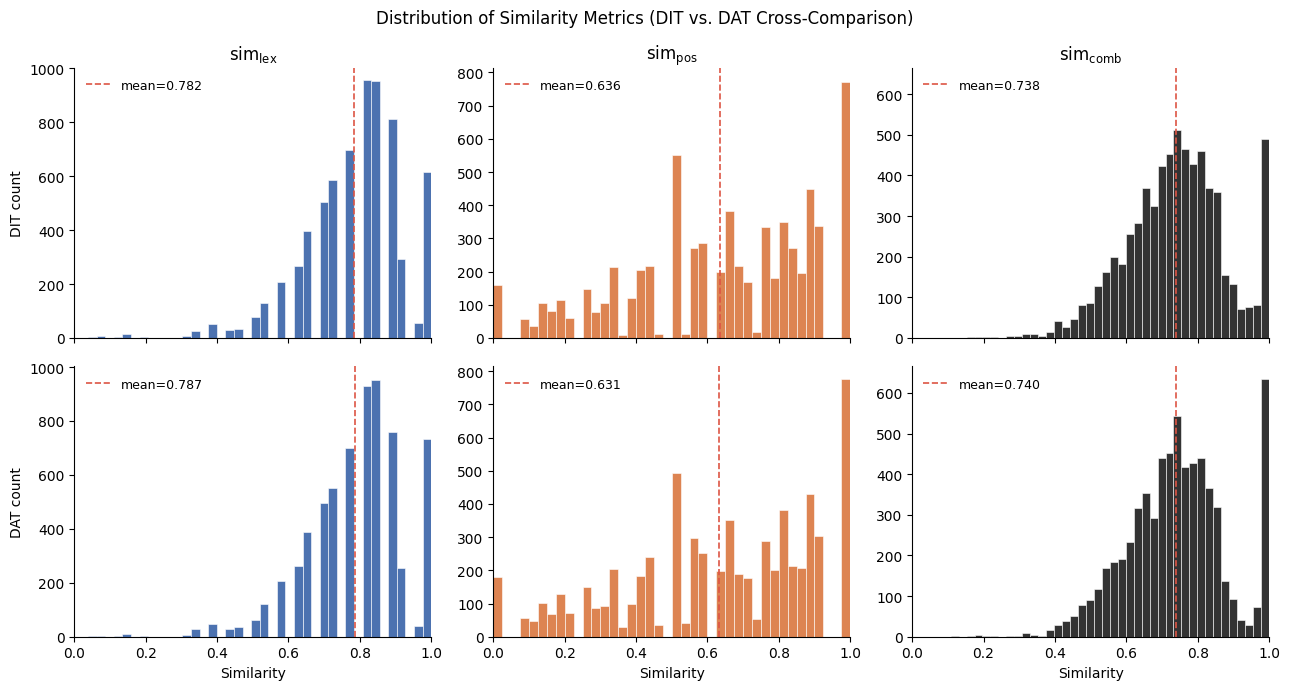

In [10]:
import matplotlib.pyplot as plt

datasets = [
    ("DIT", cross_comparison_dit),
    ("DAT", cross_comparison_dat),
]
metrics = [
    ("lexical_similarity",     r"$\mathrm{sim}_\mathrm{lex}$",  "#4c72b0"),  # blue
    ("position_similarity", r"$\mathrm{sim}_\mathrm{pos}$",  "#dd8452"),  # orange
    ("similarity_weighted", r"$\mathrm{sim}_\mathrm{comb}$", "#333333"),  # dark gray
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey="col")
for row_idx, (name, data) in enumerate(datasets):
    for col_idx, (col, label, color) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        values = data[col].dropna()
        ax.hist(values, bins=40, color=color, edgecolor="white", linewidth=0.4)
        mean_val = values.mean()
        ax.axvline(mean_val, color="#dd5544", linestyle="--", linewidth=1.2,
                   label=f"mean={mean_val:.3f}")
        ax.set_xlim(0, 1)
        ax.legend(loc="upper left", fontsize=9, frameon=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if row_idx == 0:
            ax.set_title(label)
        if row_idx == len(datasets) - 1:
            ax.set_xlabel("Similarity")
        if col_idx == 0:
            ax.set_ylabel(f"{name} count")

fig.suptitle("Distribution of Similarity Metrics (DIT vs. DAT Cross-Comparison)")
plt.tight_layout()
plt.show()
